Bayesian MMM Project-
We want to understand:
How different marketing channels (TV, Radio, Newspaper) influence Sales, and how confident we are about their impact using a Bayesian approach.

In [1]:
!pip install pymc
!pip install arviz

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

g++ not available, if using conda: `conda install gxx`


In [3]:
data = pd.read_csv("advertising.csv")
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
data.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [7]:
data.duplicated

<bound method DataFrame.duplicated of      Unnamed: 0     TV  Radio  Newspaper  Sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]>

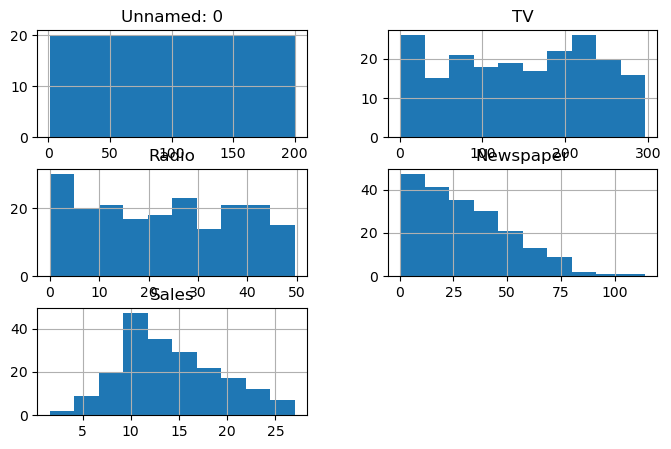

In [8]:
data.hist(figsize=(8,5))
plt.show()

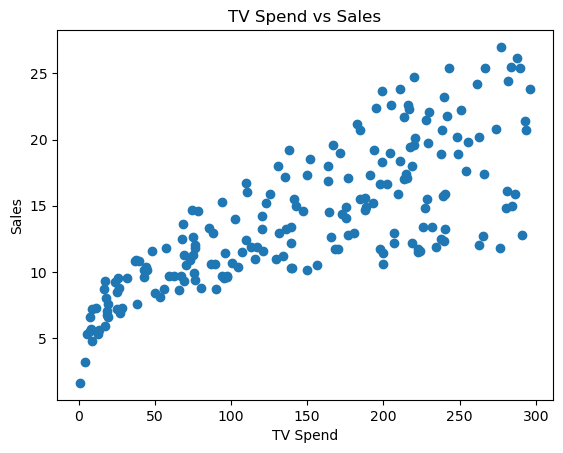

In [9]:
plt.scatter(data["TV"], data["Sales"])
plt.title("TV Spend vs Sales")
plt.xlabel("TV Spend")
plt.ylabel("Sales")
plt.show()

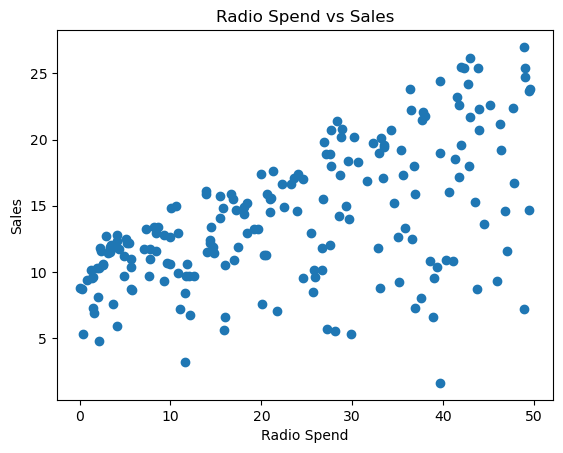

In [10]:
plt.scatter(data["Radio"], data["Sales"])
plt.title("Radio Spend vs Sales")
plt.xlabel("Radio Spend")
plt.ylabel("Sales")
plt.show()

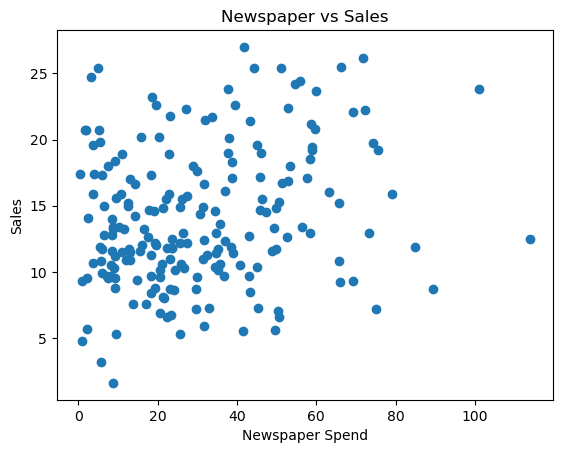

In [11]:
plt.scatter(data["Newspaper"], data["Sales"])
plt.title("Newspaper vs Sales")
plt.xlabel("Newspaper Spend")
plt.ylabel("Sales")
plt.show()

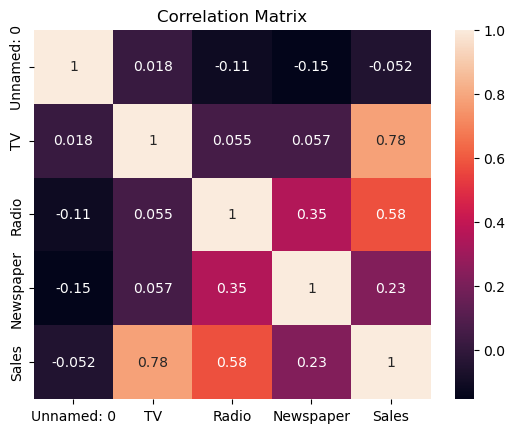

In [12]:
import seaborn as sns

corr = data.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

TV → Strong positive relation with Sales
Radio → Moderate positive relation
Newspaper → Weak relation

In [13]:
X = data[["TV", "Radio", "Newspaper"]]

In [14]:
y = data["Sales"]

In [15]:
print(X.shape)
print(y.shape)

(200, 3)
(200,)


In [16]:
print(X.head())
print(y.head())

      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [17]:
corr = data[["TV","Radio","Newspaper","Sales"]].corr()
corr

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [18]:
print(pm.__version__)

6.0.1


In [19]:
with pm.Model() as model:

    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=10
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=1,
        shape=3
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=10
    )

    mu = alpha + pm.math.dot(X, beta)

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [20]:
import arviz as az

summary = az.summary(trace)

summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,2.92,0.32,2.4,3.4,1444,1293,1.00,0.0084,0.0057
beta[0],0.0458,0.00141,0.044,0.048,1659,1195,1.00,3.5e-05,2.4e-05
beta[1],0.1888,0.0089,0.17,0.2,1266,1259,1.00,0.00025,0.00018
beta[2],-0.001,0.0059,-0.011,0.0084,1862,1494,1.00,0.00014,9.9e-05
sigma,1.694,0.083,1.6,1.8,1544,1153,1.00,0.0021,0.0016


Key Findings-
Baseline sales are approximately 2.92 units.
Radio advertising has the strongest positive impact on sales.
TV advertising contributes positively but less than Radio.
Newspaper advertising shows negligible influence on sales.
The model's estimates can be trusted because all chains converged properly.

Reccomendations-
Increase investment in Radio campaigns as it provides the strongest sales response.
Continue investing in TV advertising, but prioritize Radio when additional budget is available.
Reevaluate Newspaper advertising spend and consider reallocating part of the budget to higher-performing channels.
Maintain customer loyalty initiatives because sales are not driven entirely by advertising.
We should incorporate external business factors in future MMM models for improved accuracy.

In [21]:
results = pd.DataFrame({
    "Channel": ["TV", "Radio", "Newspaper"],
    "Impact": [
        summary.loc["beta[0]", "mean"],
        summary.loc["beta[1]", "mean"],
        summary.loc["beta[2]", "mean"]
    ],
    "Lower_Bound": [
        summary.loc["beta[0]", "eti89_lb"],
        summary.loc["beta[1]", "eti89_lb"],
        summary.loc["beta[2]", "eti89_lb"]
    ],
    "Upper_Bound": [
        summary.loc["beta[0]", "eti89_ub"],
        summary.loc["beta[1]", "eti89_ub"],
        summary.loc["beta[2]", "eti89_ub"]
    ]
})
results

,Channel,Impact,Lower_Bound,Upper_Bound
0,TV,0.0458,0.044,0.048
1,Radio,0.1888,0.17,0.2
2,Newspaper,-0.001,-0.011,0.0084


In [22]:
results.to_csv("B_MMM_results.csv", index=False)

In [23]:
results.to_csv(r"C:\Users\Windows 11 Pro\Downloads\B_MMM_results.csv", index=False)